# Distillation on synthetic traces — reasoning evals

Plots `summary_reasoning_evals.json` results for the
`distillation_on_synthetic_traces` group, one graph per model.

Each curve is one experiment, showing accuracy across training epochs.
Epoch 0 is the base model evaluated with chain-of-thought
(`base_model/<model>_cot/...`), prepended to every curve and also drawn as a
dashed reference line. Experiments whose training has not finished (no
`summary_reasoning_evals.json`) are skipped automatically, and experiments /
models / datasets are discovered from the directory tree, so re-running picks
up newly finished runs. To analyze another group, copy this notebook and change
`GROUP_NAME`.

In [4]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from core.utils.graph_style import set_style

set_style()

GROUP_NAME = "distillation_on_synthetic_traces"
SUMMARY_FILENAME = "summary_reasoning_evals.json"
BASE_EXPERIMENT = "base_model"
BASE_SUFFIX = "_cot"  # use the *_cot base_model folders for epoch 0
METRIC = "accuracy"
SAVE = True  # also write PNGs under artifacts/<group>/<dataset>/plots/


def find_artifacts_dir(start: Path | None = None) -> Path:
    """Walk up from `start` (cwd by default) until an `artifacts/` dir is found."""
    start = (start or Path.cwd()).resolve()
    for d in [start, *start.parents]:
        if (d / "artifacts").is_dir():
            return d / "artifacts"
    raise FileNotFoundError("artifacts/ not found above cwd")


ARTIFACTS = find_artifacts_dir()
GROUP_DIR = ARTIFACTS / GROUP_NAME
GROUP_DIR

PosixPath('/Users/aigoncharov/dev/sktech/recursive_caft/artifacts/distillation_on_synthetic_traces')

In [5]:
def load_curves(dataset_dir: Path) -> dict:
    """model -> experiment -> eval_key -> sorted [(epoch, metric)].

    Skips the base_model folder and any model dir without a finished summary.
    """
    data: dict = {}
    for exp_dir in sorted(dataset_dir.iterdir()):
        if not exp_dir.is_dir() or exp_dir.name == BASE_EXPERIMENT:
            continue
        for model_dir in sorted(exp_dir.iterdir()):
            if not model_dir.is_dir():
                continue
            summary = model_dir / SUMMARY_FILENAME
            if not summary.is_file():
                continue  # training not finished yet
            content = json.loads(summary.read_text())
            for eval_key, records in content.items():
                points = sorted(
                    (r["epoch"], r[METRIC])
                    for r in records
                    if r.get("epoch") is not None and r.get(METRIC) is not None
                )
                data.setdefault(model_dir.name, {}).setdefault(exp_dir.name, {})[eval_key] = points
    return data


def load_base(dataset_dir: Path, model: str) -> dict:
    """eval_key -> epoch-0 accuracy from the *_cot base_model folder."""
    out: dict = {}
    base_dir = dataset_dir / BASE_EXPERIMENT / f"{model}{BASE_SUFFIX}"
    if base_dir.is_dir():
        for results in sorted(base_dir.glob("*/results.json")):
            out[results.parent.name] = json.loads(results.read_text())[METRIC]
    return out

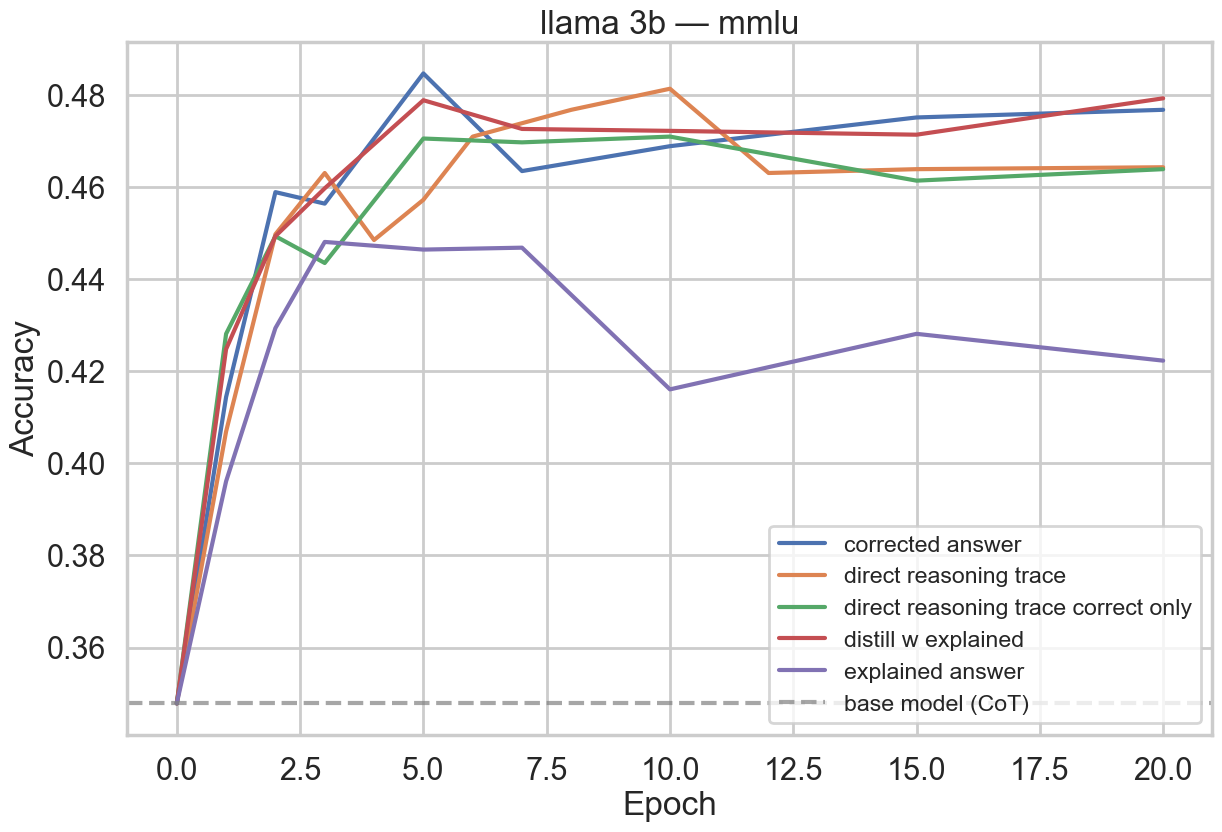

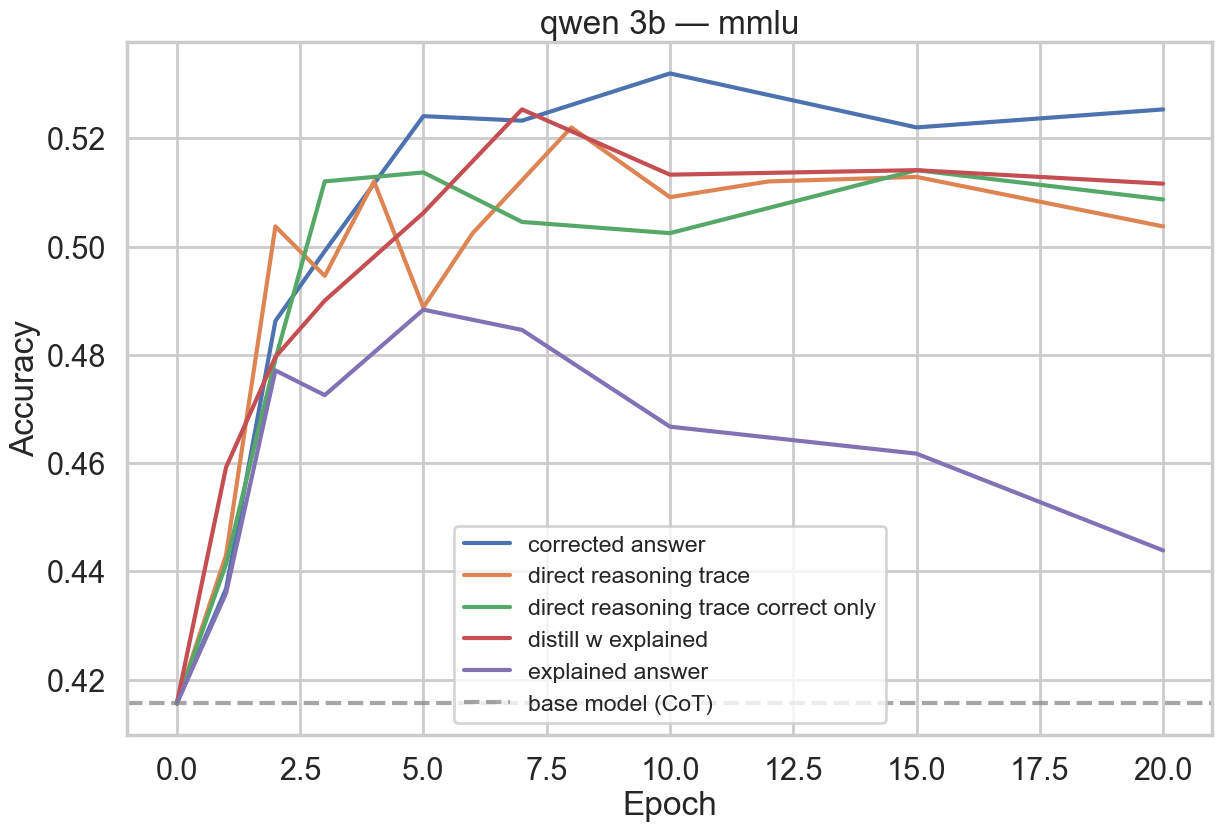

In [6]:
datasets = sorted(p.name for p in GROUP_DIR.iterdir() if p.is_dir())

for dataset in datasets:
    dataset_dir = GROUP_DIR / dataset
    curves = load_curves(dataset_dir)

    for model in sorted(curves):
        base = load_base(dataset_dir, model)
        eval_keys = {key for exp in curves[model].values() for key in exp}
        multi = len(eval_keys) > 1  # disambiguate labels only if needed

        fig, ax = plt.subplots(figsize=(14, 9))

        for experiment in sorted(curves[model]):
            for eval_key, points in curves[model][experiment].items():
                xs = [e for e, _ in points]
                ys = [v for _, v in points]
                if eval_key in base:  # anchor every curve at the epoch-0 base
                    xs = [0.0] + xs
                    ys = [base[eval_key]] + ys
                label = experiment.replace("_", " ")
                if multi:
                    label = f"{label} [{eval_key}]"
                ax.plot(xs, ys, label=label)

        for eval_key, acc in base.items():  # base reference line(s)
            ref_label = "base model (CoT)" + (f" [{eval_key}]" if multi else "")
            ax.axhline(acc, ls="--", color="gray", alpha=0.7, label=ref_label)

        ax.set_title(f"{model.replace('_', ' ')} — {dataset}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(METRIC.capitalize())
        ax.legend(fontsize="x-small", loc="best")

        if SAVE:
            plots_dir = dataset_dir / "plots"
            plots_dir.mkdir(parents=True, exist_ok=True)
            fig.savefig(
                plots_dir / f"{model}_reasoning_evals.png",
                bbox_inches="tight",
                dpi=150,
            )

        plt.show()